### Imports

In [155]:
import numpy as np 
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [156]:
df = pd.read_csv("/kaggle/input/datasets/mobeenfatimah/diabetes-risk-prediction-dataset-50k-patients/diabetes_risk_prediction_dataset.csv")

### Understanding the data

In [157]:
df.head()

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High


In [158]:
df.drop(columns ="Patient_ID",inplace = True)

In [159]:
df.columns

Index(['Age', 'Gender', 'Country', 'Height_cm', 'Weight_kg', 'BMI',
       'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c',
       'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL',
       'Triglycerides', 'Heart_Rate', 'Physical_Activity_Level',
       'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Diet_Quality',
       'Sugar_Intake_Level', 'Sleep_Hours', 'Stress_Level', 'Smoking_Status',
       'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension',
       'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Medication_Adherence',
       'Work_Type', 'Residence_Type', 'Daily_Water_Intake_L',
       'Diabetes_Risk_Score', 'AI_Health_Recommendation',
       'Doctor_Consultation_Needed', 'Diabetes_Risk'],
      dtype='object')

In [160]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,...,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
count,49503.000000,47055.000000,47038.000000,50000.000000,50000.000000,49041.000000,48026.000000,50000.000000,50000.000000,50000.000000,...,49000.000000,49000.000000,49000.000000,49000.000000,50000.000000,48008.000000,48036.000000,47983.000000,50000.000000,50000.000000
mean,53.871099,170.018814,87.457003,30.924056,99.960790,159.905245,8.488061,142.607294,23.476724,140.171120,...,220.168635,57.371731,135.014524,229.543259,85.124260,5.017460,89.933442,6.500917,2.998842,74.043920
std,21.130148,14.457787,24.500358,10.290091,23.086579,52.040575,2.313758,44.681799,12.403841,29.168623,...,57.793626,18.720696,49.135613,98.234911,20.390334,2.875922,52.034642,2.027793,1.152273,15.598327
min,18.000000,145.000000,45.000000,11.900000,60.000000,70.000000,4.500000,65.000000,2.000000,90.000000,...,120.000000,25.000000,50.000000,60.000000,50.000000,0.000000,0.000000,3.000000,1.000000,13.000000
25%,35.000000,157.600000,66.300000,22.700000,80.000000,114.700000,6.500000,103.900000,12.800000,115.000000,...,169.800000,41.300000,92.500000,144.700000,68.000000,2.500000,44.900000,4.700000,2.000000,64.000000
50%,54.000000,170.000000,87.300000,30.000000,99.800000,159.900000,8.500000,142.600000,23.400000,140.000000,...,220.400000,57.300000,135.100000,229.500000,85.000000,5.000000,89.800000,6.500000,3.000000,75.000000
75%,72.000000,182.600000,108.600000,37.800000,119.900000,205.100000,10.500000,181.500000,34.300000,165.000000,...,270.500000,73.600000,177.700000,314.600000,103.000000,7.500000,135.200000,8.300000,4.000000,86.000000
max,90.000000,195.000000,130.000000,61.700000,140.000000,250.000000,12.500000,220.000000,45.000000,190.000000,...,320.000000,90.000000,220.000000,400.000000,120.000000,10.000000,180.000000,10.000000,5.000000,100.000000


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         49503 non-null  float64
 1   Gender                      50000 non-null  object 
 2   Country                     50000 non-null  object 
 3   Height_cm                   47055 non-null  float64
 4   Weight_kg                   47038 non-null  float64
 5   BMI                         50000 non-null  float64
 6   Waist_Circumference_cm      50000 non-null  float64
 7   Blood_Glucose               49041 non-null  float64
 8   HbA1c                       48026 non-null  float64
 9   Fasting_Blood_Sugar         50000 non-null  float64
 10  Insulin_Level               50000 non-null  float64
 11  Blood_Pressure_Systolic     50000 non-null  int64  
 12  Blood_Pressure_Diastolic    50000 non-null  int64  
 13  Total_Cholesterol           490

In [162]:
num_cols = df.select_dtypes(include='number').columns.tolist()

num_summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Std': df[num_cols].std(),
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurtosis()
})
print(num_summary)

                                Mean        Std  Skewness  Kurtosis
Age                        53.871099  21.130148  0.007513 -1.206366
Height_cm                 170.018814  14.457787  0.000421 -1.206541
Weight_kg                  87.457003  24.500358  0.004245 -1.191423
BMI                        30.924056  10.290091  0.431769 -0.453116
Waist_Circumference_cm     99.960790  23.086579  0.009688 -1.191417
Blood_Glucose             159.905245  52.040575  0.006298 -1.211848
HbA1c                       8.488061   2.313758  0.001709 -1.203790
Fasting_Blood_Sugar       142.607294  44.681799 -0.001238 -1.199559
Insulin_Level              23.476724  12.403841  0.005540 -1.199893
Blood_Pressure_Systolic   140.171120  29.168623 -0.003759 -1.200772
Blood_Pressure_Diastolic   90.039000  17.575503 -0.009580 -1.193411
Total_Cholesterol         220.168635  57.793626 -0.005053 -1.202765
HDL                        57.371731  18.720696  0.003958 -1.195463
LDL                       135.014524  49.135613 

### Filling missing values and nans

In [163]:
missing_cols = df.isna().sum()[df.isna().sum() > 0]
missing_cols

Age                         497
Height_cm                  2945
Weight_kg                  2962
Blood_Glucose               959
HbA1c                      1974
Total_Cholesterol          1000
HDL                        1000
LDL                        1000
Triglycerides              1000
Physical_Activity_Level     500
Exercise_Hours_Per_Week    1992
Daily_Walking_Minutes      1964
Sleep_Hours                2017
Medication_Adherence       1000
dtype: int64

In [164]:
mean_cols = [
    'Height_cm', 'Weight_kg', 'Sleep_Hours'
]

In [165]:
most_frequent_cols = [
    'Physical_Activity_Level', 'Medication_Adherence'
]

In [166]:
median_cols = [
    'Age', 'Blood_Glucose', 'HbA1c', 'Total_Cholesterol', 
    'HDL', 'LDL', 'Triglycerides', 'Exercise_Hours_Per_Week', 
    'Daily_Walking_Minutes'
]

In [167]:
imputer_transformer = ColumnTransformer(transformers=[
    ('mean_impute', SimpleImputer(strategy='mean'), mean_cols),
    ('median_impute', SimpleImputer(strategy='median'), median_cols),
    ('mode_impute', SimpleImputer(strategy='most_frequent'), most_frequent_cols)
], remainder='passthrough') 

In [168]:
all_imputed_cols = mean_cols + median_cols + most_frequent_cols
df[all_imputed_cols] = imputer_transformer.fit_transform(df[all_imputed_cols])

In [169]:
df.isna().sum()[df.isna().sum()>2]

Series([], dtype: int64)

### Type conversions

In [170]:
num_cols = ['Age','Height_cm','Weight_kg','Blood_Glucose','HbA1c','Total_Cholesterol','HDL','LDL','Triglycerides','Exercise_Hours_Per_Week','Daily_Walking_Minutes','Sleep_Hours']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

In [171]:
df.dtypes

Age                           float64
Gender                         object
Country                        object
Height_cm                     float64
Weight_kg                     float64
BMI                           float64
Waist_Circumference_cm        float64
Blood_Glucose                 float64
HbA1c                         float64
Fasting_Blood_Sugar           float64
Insulin_Level                 float64
Blood_Pressure_Systolic         int64
Blood_Pressure_Diastolic        int64
Total_Cholesterol             float64
HDL                           float64
LDL                           float64
Triglycerides                 float64
Heart_Rate                      int64
Physical_Activity_Level        object
Exercise_Hours_Per_Week       float64
Daily_Walking_Minutes         float64
Diet_Quality                   object
Sugar_Intake_Level             object
Sleep_Hours                   float64
Stress_Level                   object
Smoking_Status                 object
Alcohol_Cons

In [172]:
for col in df.select_dtypes(include='float').columns:
    if df[col].dropna().mod(1).eq(0).all():
        df[col] = df[col].astype('Int64')

In [173]:
df.dtypes

Age                             Int64
Gender                         object
Country                        object
Height_cm                     float64
Weight_kg                     float64
BMI                           float64
Waist_Circumference_cm        float64
Blood_Glucose                 float64
HbA1c                         float64
Fasting_Blood_Sugar           float64
Insulin_Level                 float64
Blood_Pressure_Systolic         int64
Blood_Pressure_Diastolic        int64
Total_Cholesterol             float64
HDL                           float64
LDL                           float64
Triglycerides                 float64
Heart_Rate                      int64
Physical_Activity_Level        object
Exercise_Hours_Per_Week       float64
Daily_Walking_Minutes         float64
Diet_Quality                   object
Sugar_Intake_Level             object
Sleep_Hours                   float64
Stress_Level                   object
Smoking_Status                 object
Alcohol_Cons

### Visualizations : 

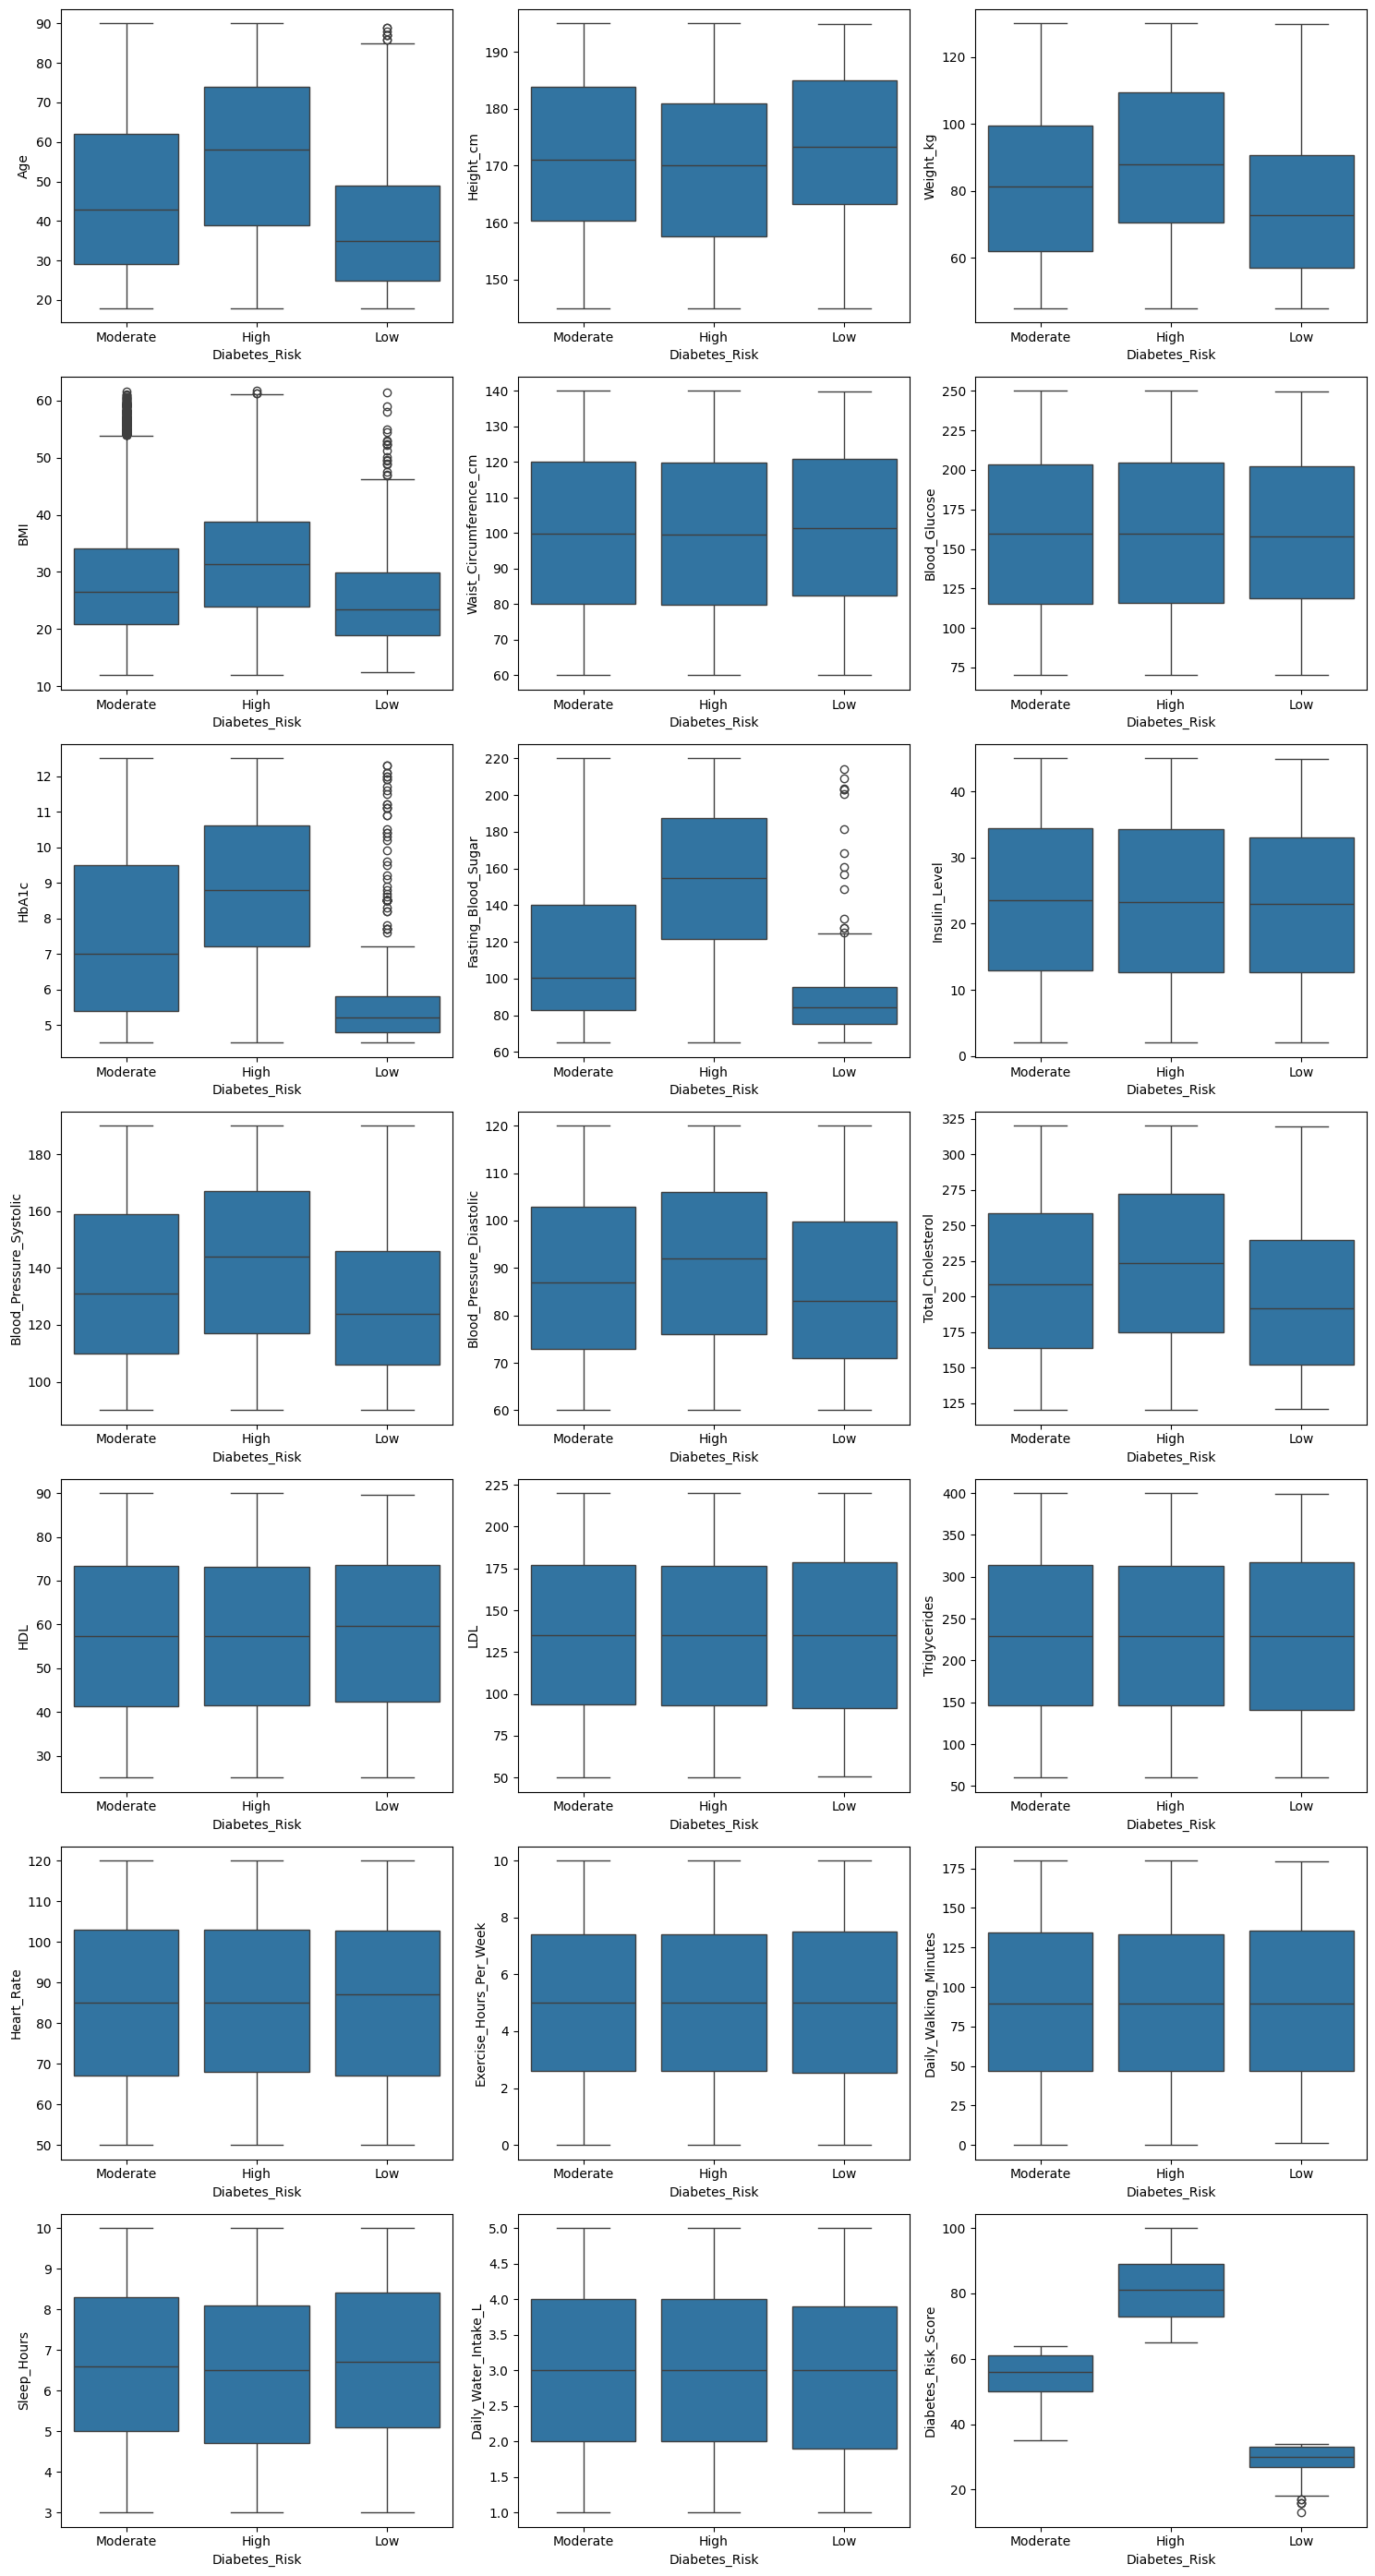

In [174]:
NUMERIC_COLS = df.select_dtypes(include='number').columns[df.select_dtypes(include='number').nunique() > 10]
fig, axes = plt.subplots((len(NUMERIC_COLS)+2)//3, 3, figsize=(15, 4*((len(NUMERIC_COLS)+2)//3)))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_COLS): sns.boxplot(x=df['Diabetes_Risk'].astype(str), y=df[col], ax=axes[i])
for i in range(len(NUMERIC_COLS), len(axes)): fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

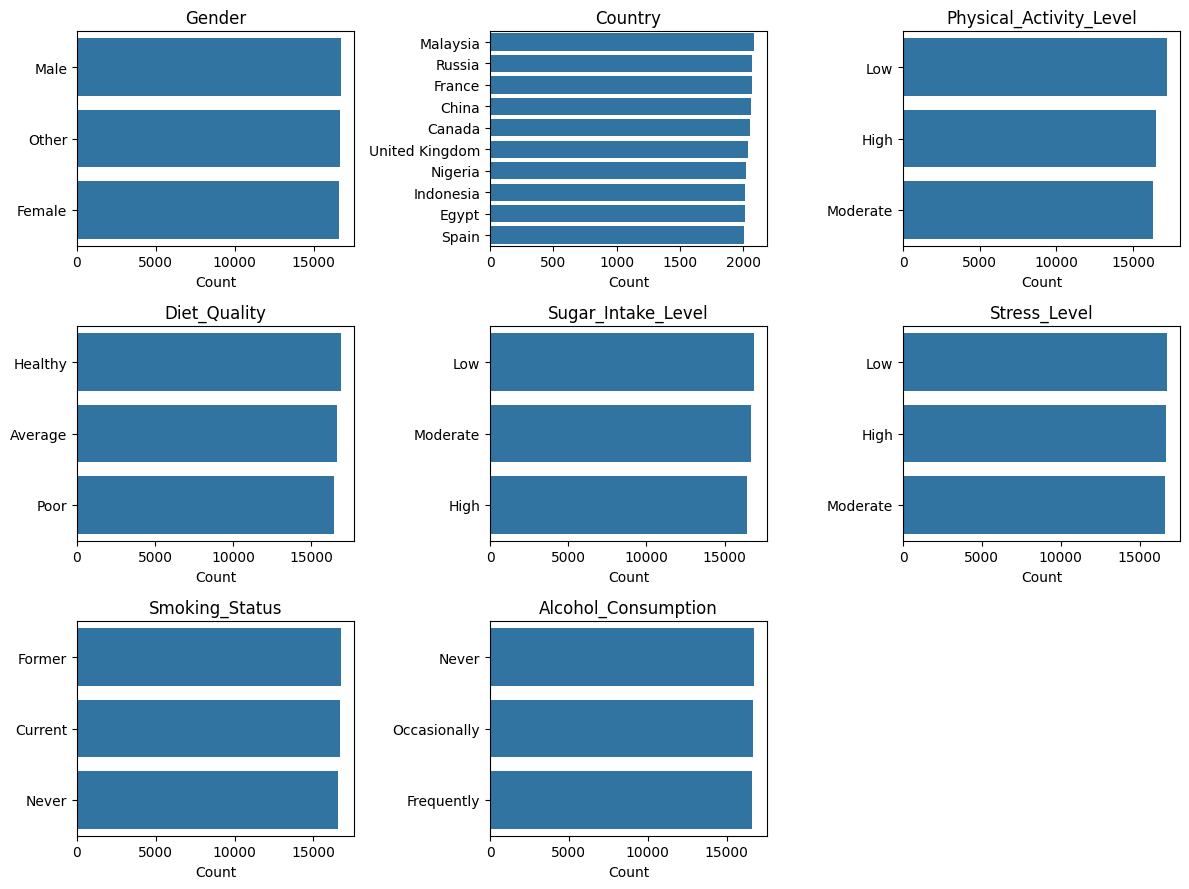

In [175]:
cat_cols = df.select_dtypes(include='object').columns[:8]
nrows = int(np.ceil(len(cat_cols) / 3))

fig, axes = plt.subplots(nrows, 3, figsize=(12, 3*nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(cat_cols):
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("")
    axes[i].set_xlabel("Count")

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

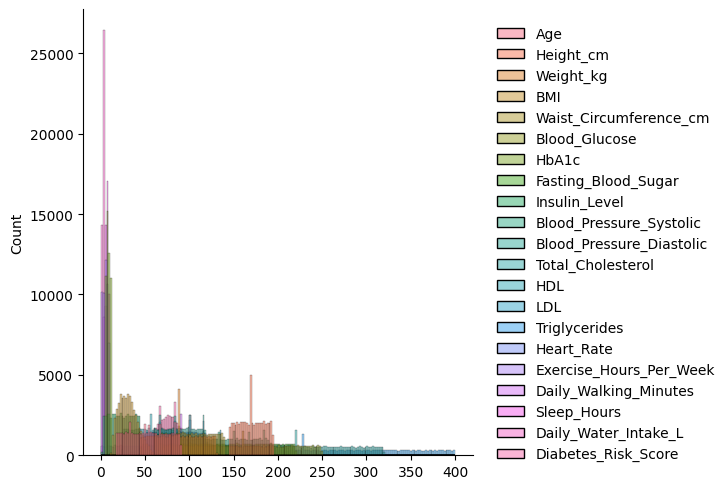

In [176]:
sns.displot(data=df);

### Encoding, Pipeline creation and  Scaling :

In [177]:
from sklearn.model_selection import train_test_split
X = df.drop([
    'Diabetes_Risk',
    'Diabetes_Risk_Score',
    'AI_Health_Recommendation',
    'Doctor_Consultation_Needed'
], axis=1)

Y = df['Diabetes_Risk']
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [178]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include='object').columns

In [179]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

Preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown = 'ignore'), cat_cols)
])

### Model Training

In [194]:
from sklearn.ensemble import RandomForestClassifier
model = Pipeline([
    ('preprocessor', Preprocessor),
    ('classifier', RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
))
])
model.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm',
       'Blood_Glucose', 'HbA1c', 'Fasting_Blood_Sugar', 'Insulin_Level',
       'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic',
       'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Heart_Rate',
       'Exercise_Hours_Pe...
                                                  Index(['Gender', 'Country', 'Physical_Activity_Level', 'Diet_Quality',
       'Sugar_Intake_Level', 'Stress_Level', 'Smoking_Status',
       'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension',
       'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Medication_Adherence',
       'Work_Type', 'Residence_Type'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [195]:
Y_pred = model.predict(X_test)

In [196]:
from sklearn.metrics import accuracy_score, classification_report
print(accuracy_score(Y_test, Y_pred))

0.8804


In [198]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
report = pd.DataFrame(
    classification_report(Y_test, Y_pred, output_dict=True)
).T
report

,precision,recall,f1-score,support
High,0.872981,0.991785,0.928599,7304.0000
Low,0.000000,0.000000,0.000000,82.0000
Moderate,0.916569,0.596787,0.722892,2614.0000
accuracy,0.880400,0.880400,0.880400,0.8804
macro avg,0.596517,0.529524,0.550497,10000.0000
weighted avg,0.877217,0.880400,0.867212,10000.0000


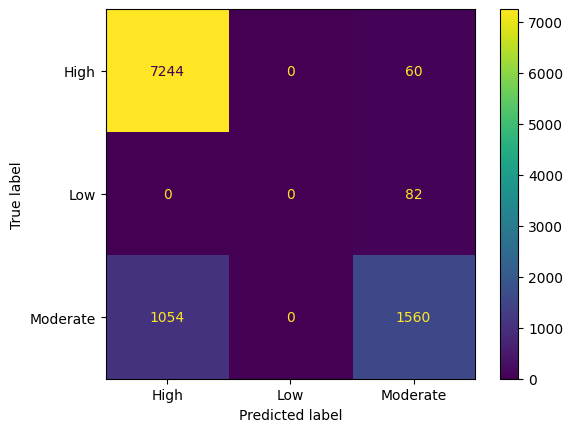

In [199]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred)
plt.show()

### Using SMOTE

**class_weight='balanced' gave basically the same result, then the issue of model getting no recall is deeper only 82 Low samples exist in the test set, and the features may not be providing enough separation for the model to learn that class.Hence , trying SMOTE on the training data. Keeping the test set untouched.**

In [203]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
model = Pipeline([
    ('preprocessor', Preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [204]:
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

In [206]:
report = pd.DataFrame(
    classification_report(Y_test, Y_pred, output_dict=True)
).T

report

,precision,recall,f1-score,support
High,0.916200,0.963992,0.939489,7304.0000
Low,0.750000,0.036585,0.069767,82.0000
Moderate,0.852012,0.753252,0.799594,2614.0000
accuracy,0.901300,0.901300,0.901300,0.9013
macro avg,0.839404,0.584610,0.602950,10000.0000
weighted avg,0.898059,0.901300,0.895789,10000.0000


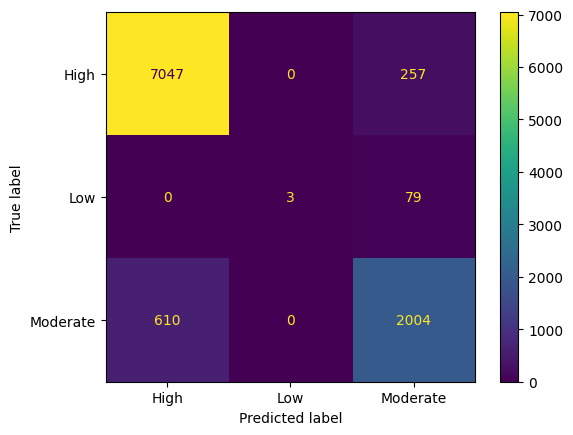

In [216]:
ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred);

### Tunning the class weights 
for a more specific model attention to be grabbed to low class i am making changes in claass weights. 

In [209]:
model = Pipeline([
    ('preprocessor', Preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
    n_estimators=300,
    class_weight={
        'High': 1,
        'Moderate': 1,
        'Low': 10
    },
    random_state=42,
    n_jobs=-1
))
])

In [210]:
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)

In [211]:
report = pd.DataFrame(
    classification_report(Y_test, Y_pred, output_dict=True)
).T

report

,precision,recall,f1-score,support
High,0.920334,0.964814,0.942049,7304.0000
Low,1.000000,0.036585,0.070588,82.0000
Moderate,0.856410,0.766641,0.809043,2614.0000
accuracy,0.905400,0.905400,0.905400,0.9054
macro avg,0.925582,0.589347,0.607227,10000.0000
weighted avg,0.904278,0.905400,0.900136,10000.0000


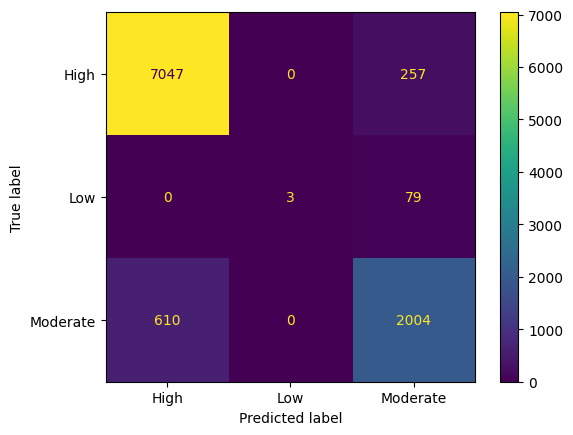

In [217]:
ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred);

In [218]:
df.groupby('Diabetes_Risk').mean(numeric_only=True).T

Diabetes_Risk,High,Low,Moderate
Age,56.503238,38.942553,46.973255
Height_cm,169.393768,173.476493,171.661174
Weight_kg,89.487054,76.403943,82.116451
BMI,31.918181,25.597447,28.305635
Waist_Circumference_cm,99.905523,100.84617,100.08495
Blood_Glucose,160.070765,159.032766,159.46837
HbA1c,8.844386,5.781702,7.58032
Fasting_Blood_Sugar,152.775777,88.441915,115.813017
Insulin_Level,23.435687,23.051915,23.608232
Blood_Pressure_Systolic,142.251496,127.976596,134.72969


In [219]:
df[df['Diabetes_Risk'] == 'Low'].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,470.0,38.942553,17.085602,18.0,25.0,35.0,49.0,89.0
Height_cm,470.0,173.476493,13.328801,145.0,163.325,173.25,184.975,194.9
Weight_kg,470.0,76.403943,22.585699,45.0,56.9,72.85,90.75,129.9
BMI,470.0,25.597447,9.220705,12.4,18.9,23.4,29.9,61.4
Waist_Circumference_cm,470.0,100.84617,22.709418,60.1,82.325,101.5,120.775,139.8
Blood_Glucose,470.0,159.032766,50.35963,70.3,118.65,157.95,202.175,249.4
HbA1c,470.0,5.781702,1.634452,4.5,4.8,5.2,5.8,12.3
Fasting_Blood_Sugar,470.0,88.441915,20.795716,65.1,75.45,84.25,95.225,214.1
Insulin_Level,470.0,23.051915,12.334099,2.0,12.7,23.05,33.05,44.9
Blood_Pressure_Systolic,470.0,127.976596,27.332617,90.0,106.0,124.0,146.0,190.0


In [220]:
pd.crosstab(df['Diabetes_Risk'], pd.cut(df['Diabetes_Risk_Score'], bins=10))

Diabetes_Risk_Score,"(12.913, 21.7]","(21.7, 30.4]","(30.4, 39.1]","(39.1, 47.8]","(47.8, 56.5]","(56.5, 65.2]","(65.2, 73.9]","(73.9, 82.6]","(82.6, 91.3]","(91.3, 100.0]"
Diabetes_Risk,,,,,,,,,,
High,0,0,0,0,0,1007,8708,10897,8898,7083
Low,30,207,233,0,0,0,0,0,0,0
Moderate,0,0,509,1750,4310,6368,0,0,0,0


In [221]:
df.groupby('Diabetes_Risk')['Diabetes_Risk_Score'].agg(['min','max','mean'])

,min,max,mean
Diabetes_Risk,,,
High,65,100,81.409122
Low,13,34,29.236170
Moderate,35,64,54.838912


### Data Leakage Detection & Final Conclusion

> Diabetes_Risk_Score was excluded because the target classes are directly defined by its score ranges: Low (13–34), Moderate (35–64), and High (65–100).

> Including this feature resulted in near-perfect accuracy (~99.99%), indicating target leakage rather than genuine predictive performance.
The dataset is also highly imbalanced, with the Low-risk class representing only ~0.94% of the data.

> After removing leakage-prone features and addressing class imbalance, the model achieved approximately 90.5% accuracy, with performance evaluated using class-wise precision, recall, F1-score, and the confusion matrix.

Therefore, I consider the leakage-free results to be the more valid representation of the model's predictive performance and conclude the modeling process here rather than artificially optimizing the results.

### **Thankyouu** for reading this notebook. If you like my work , Do Upvote !!